# Cluster Stories with K-Means

Goal: cluster the stories using text alone, then inspect whether the clusters show anything interesting related to author pronouns, genre/category, or represented gender.

- The algorithm groups stories based on similarity in word usage

## Text Representation 
TF-IDF (Term Frequency–Inverse Document Frequency):
- How often a word appears in a document
- How unique that word is across all documents


## Dimensionality Reduction (SVD)

TF-IDF produces a high-dimensional dataset, which can be noisy/inefficient for clustering.

SVD (Singular Value Decomposition):
- Reduce dimensionality
- Capture the most important patterns in word usage
- Improve clustering performance


In [40]:
import re
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

from stop_words import stop_word_list

DATA_PATH = Path("data/compiled_stats.csv")
TEXT_DIR = Path("text/Texts")

RANDOM_STATE = 42
K = 5

In [41]:
stats = pd.read_csv(DATA_PATH)

fiction = stats[stats["Type"] == "Original Fiction"].copy()

fiction["pronoun_clean"] = fiction["Pronoun"].str.lower().str.strip()
fiction["category_clean"] = fiction["Category"].fillna("Unknown")

print("Original fiction rows:", len(fiction))

fiction[["Title", "Author", "Pronoun", "Category"]].head()

Original fiction rows: 661


,Title,Author,Pronoun,Category
1,Down on the Farm,Charles Stross,He/him,Fantasy
2,After the Coup,John Scalzi,He/him,Science Fiction
4,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,NaN
5,Shade,Steven Gould,He/him,NaN
6,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Fantasy


In [42]:
def read_docx_text(path):
    paragraphs = []

    with zipfile.ZipFile(path) as docx_zip:
        xml = docx_zip.read("word/document.xml")

    root = ET.fromstring(xml)
    namespace = {"w": "http://schemas.openxmlformats.org/wordprocessingml/2006/main"}

    for paragraph in root.findall(".//w:p", namespace):
        text_parts = [
            node.text
            for node in paragraph.findall(".//w:t", namespace)
            if node.text
        ]
        if text_parts:
            paragraphs.append("".join(text_parts))

    return "\n".join(paragraphs)


def normalize_title(title):
    title = str(title).lower()
    title = re.sub(r"[^a-z0-9]+", " ", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title


def parse_filename(path):
    match = re.match(r"^(\d+)\s*(.*)$", path.stem)

    if match:
        return int(match.group(1)), match.group(2).strip()

    return None, path.stem

In [43]:
rows = []

for path in sorted(TEXT_DIR.glob("*.docx")):
    file_id, file_title = parse_filename(path)

    rows.append({
        "filename": path.name,
        "file_id": file_id,
        "file_title": file_title,
        "title_clean": normalize_title(file_title),
        "text": read_docx_text(path),
    })

texts = pd.DataFrame(rows)

print("Loaded text files:", len(texts))

texts.head()

Loaded text files: 762


,filename,file_id,file_title,title_clean,text
0,002 Down on the Farm.docx,2,Down on the Farm,down on the farm,"Ah, the joy of summer: here in the south-east ..."
1,003 After the Coup.docx,3,After the Coup,after the coup,“How well can you take a punch?” asked Deputy ...
2,006 The Things That Make Me Weak and Strange G...,6,The Things That Make Me Weak and Strange Get E...,the things that make me weak and strange get e...,"’Cause it’s gonna be the future soon,And I won..."
3,007 Shade.docx,7,Shade,shade,Xareed had been waiting for the water truck fo...
4,008 The Girl Who Sang Rose Madder.docx,8,The Girl Who Sang Rose Madder,the girl who sang rose madder,A real backstage mostly resembles the opening ...


In [44]:
fiction["title_clean"] = fiction["Title"].map(normalize_title)

story_df = texts.merge(
    fiction,
    on="title_clean",
    how="inner"
)

print("Matched stories:", len(story_df))

story_df[["filename", "Title", "Author", "Pronoun", "Category"]].head()

Matched stories: 625


,filename,Title,Author,Pronoun,Category
0,002 Down on the Farm.docx,Down on the Farm,Charles Stross,He/him,Fantasy
1,003 After the Coup.docx,After the Coup,John Scalzi,He/him,Science Fiction
2,006 The Things That Make Me Weak and Strange G...,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,NaN
3,007 Shade.docx,Shade,Steven Gould,He/him,NaN
4,008 The Girl Who Sang Rose Madder.docx,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Fantasy


In [45]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stop_word_list,
    max_features=10000,
    min_df=5,
    max_df=0.85
)

X_tfidf = vectorizer.fit_transform(story_df["text"])

print("TF-IDF shape:", X_tfidf.shape)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['articl', 'mon'] not in stop_words.
  warnings.warn(


TF-IDF shape: (625, 10000)


In [46]:
n_components = min(50, X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=RANDOM_STATE
)

X_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_svd.shape)
print("Explained variance:", round(svd.explained_variance_ratio_.sum(), 3))

SVD shape: (625, 50)
Explained variance: 0.237


In [47]:
kmeans = KMeans(
    n_clusters=K,
    random_state=RANDOM_STATE,
    n_init=20
)

story_df["cluster"] = kmeans.fit_predict(X_svd)

story_df["cluster"].value_counts().sort_index()

cluster
0    165
1    441
2      4
3      4
4     11
Name: count, dtype: int64

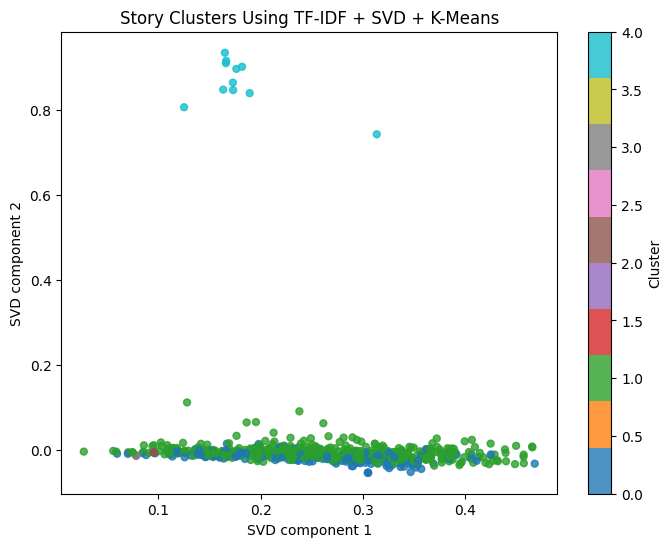

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_svd[:, 0],
    X_svd[:, 1],
    c=story_df["cluster"],
    cmap="tab10",
    s=25,
    alpha=0.8
)

plt.title("Story Clusters Using TF-IDF + SVD + K-Means")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.colorbar(label="Cluster")
plt.show()

In [49]:
pronoun_counts = pd.crosstab(
    story_df["cluster"],
    story_df["pronoun_clean"]
)

pronoun_percent = pd.crosstab(
    story_df["cluster"],
    story_df["pronoun_clean"],
    normalize="index"
).round(3)

display(pronoun_counts)
display(pronoun_percent)

pronoun_clean,he/him,she/her,they/them,ær/ærs
cluster,,,,
0,61,87,9,1
1,227,194,12,0
2,0,0,2,0
3,0,4,0,0
4,11,0,0,0


pronoun_clean,he/him,she/her,they/them,ær/ærs
cluster,,,,
0,0.386,0.551,0.057,0.006
1,0.524,0.448,0.028,0.000
2,0.000,0.000,1.000,0.000
3,0.000,1.000,0.000,0.000
4,1.000,0.000,0.000,0.000


In [50]:
category_counts = pd.crosstab(
    story_df["cluster"],
    story_df["category_clean"]
)

category_percent = pd.crosstab(
    story_df["cluster"],
    story_df["category_clean"],
    normalize="index"
).round(3)

display(category_counts)
display(category_percent)

category_clean,Alternate History,Apocalyptic and Post-Apocalyptic,Book Excerpt,Contemporary Fantasy,Cyberpunk,Dark Fantasy,Detective,Dystopian,Epic Fantasy,Fairy Tales and Folklore,...,Humor,Magical Realism,Military Science Fiction,Reprint,Romantic,Science Fiction,Space Opera,Steampunk,Unknown,Urban Fantasy
cluster,,,,,,,,,,,,,,,,,,,,,
0,4,0,0,2,0,10,2,1,1,5,...,3,2,1,2,1,31,0,0,60,0
1,10,8,1,18,3,26,2,9,16,9,...,7,1,0,4,3,81,1,1,135,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,2,0


category_clean,Alternate History,Apocalyptic and Post-Apocalyptic,Book Excerpt,Contemporary Fantasy,Cyberpunk,Dark Fantasy,Detective,Dystopian,Epic Fantasy,Fairy Tales and Folklore,...,Humor,Magical Realism,Military Science Fiction,Reprint,Romantic,Science Fiction,Space Opera,Steampunk,Unknown,Urban Fantasy
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.024,0.000,0.000,0.012,0.000,0.061,0.012,0.006,0.006,0.03,...,0.018,0.012,0.006,0.012,0.006,0.188,0.000,0.000,0.364,0.000
1,0.023,0.018,0.002,0.041,0.007,0.059,0.005,0.020,0.036,0.02,...,0.016,0.002,0.000,0.009,0.007,0.184,0.002,0.002,0.306,0.002
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,...,0.000,0.000,0.000,0.500,0.000,0.000,0.000,0.000,0.500,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,...,0.000,0.000,0.000,0.500,0.500,0.000,0.000,0.000,0.000,0.000
4,0.636,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,...,0.091,0.000,0.000,0.000,0.000,0.091,0.000,0.000,0.182,0.000


In [51]:
for cluster_id in sorted(story_df["cluster"].unique()):
    print(f"\nCluster {cluster_id}")

    display(
        story_df.loc[
            story_df["cluster"] == cluster_id,
            ["Title", "Author", "Pronoun", "Category"]
        ].head(10)
    )


Cluster 0


,Title,Author,Pronoun,Category
0,Down on the Farm,Charles Stross,He/him,Fantasy
10,Escape to Other Worlds with Science Fiction,Jo Walton,She/her,Alternate History
13,We Haven't Got There Yet,Harry Turtledove,He/him,Science Fiction
25,The Star and the Rockets,Harry Turtledove,He/him,Science Fiction
26,The Horrid Glory of Its Wings,Elizabeth Bear,She/her,Fantasy
27,Overtime,Charles Stross,He/him,Fantasy
32,The Next Invasion,Robert Reed,He/him,Science Fiction
43,What Makes a River,Deborah Coates,She/her,Fantasy
46,The Monster's Million Faces,Rachel Swirsky,She/her,Science Fiction
51,"Good Night, Moon",Bruce Sterling,He/him,Humor



Cluster 1


,Title,Author,Pronoun,Category
1,After the Coup,John Scalzi,He/him,Science Fiction
2,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,NaN
3,Shade,Steven Gould,He/him,NaN
4,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Fantasy
5,Catch 'Em in the Act,Terry Bisson,He/him,Contemporary Fantasy
6,"Jack and the Aktuals, or, Physical Application...",Rudy Rucker,He/him,Science Fiction
7,A Water Matter,Jay Lake,He/him,Epic Fantasy
8,Firstborn,Brandon Sanderson,He/him,Science Fiction
9,Errata,Jeff VanderMeer,He/him,Contemporary Fantasy
11,A Weeping Czar Beholds the Fallen Moon,Ken Scholes,He/him,Epic Fantasy



Cluster 2


,Title,Author,Pronoun,Category
471,Blood Is Another Word for Hunger,Rivers Solomon,They/them,NaN
472,Blood Is Another Word for Hunger,Rivers Solomon,NaN,Reprint
605,Blood Is Another Word for Hunger,Rivers Solomon,They/them,NaN
606,Blood Is Another Word for Hunger,Rivers Solomon,NaN,Reprint



Cluster 3


,Title,Author,Pronoun,Category
75,"Six Months, Three Days",Charlie Jane Anders,She/her,Romantic
76,"Six Months, Three Days",Charlie Jane Anders,she/her,Reprint
609,"Six Months, Three Days",Charlie Jane Anders,She/her,Romantic
610,"Six Months, Three Days",Charlie Jane Anders,she/her,Reprint



Cluster 4


,Title,Author,Pronoun,Category
112,The Mongolian Wizard,Michael Swanwick,He/him,Alternate History
117,The Fire Gown,Michael Swanwick,He/him,Alternate History
121,Day of the Kraken,Michael Swanwick,He/him,Alternate History
191,House of Dreams,Michael Swanwick,He/him,Alternate History
241,A Cost-Benefit Analysis of the Proposed Trade-...,John Chu,He/him,Science Fiction
297,The Night of the Salamander,Michael Swanwick,He/him,Alternate History
304,The Pyramid of Krakow,Michael Swanwick,He/him,Alternate History
311,The Phantom in the Maze,Michael Swanwick,He/him,Alternate History
317,Small Wars,Matt Wallace,He/him,Humor
465,Murder in the Spook House,Michael Swanwick,He/him,NaN
